# 🎨 Self-Organizing Map (SOM) Image Color Palette Extraction

This notebook demonstrates vector quantization and topological clustering using **Self-Organizing Maps (SOM / Kohonen Networks)** to extract cohesive color palettes from images.

---

### 🧮 Mathematical Model

1. **Best Matching Unit (BMU)**:
   $$c = \arg\min_i \| x - w_i(t) \|
$$
2. **Exponential Parameter Decay**:
   $$\alpha(t) = \alpha_0 \cdot \exp\left(-\frac{t}{T}\right), \quad \sigma(t) = \sigma_0 \cdot \exp\left(-\frac{t}{T}\right)
$$
3. **Weight Delta ($\Delta W$) & Convergence**:
   $$\Delta W = \frac{1}{M} \sum_{i=1}^M \| w_i(t) - w_i(t-1) \|
$$
4. **Quantization Error ($QE$)**:
   $$QE = \frac{1}{N} \sum_{k=1}^N \| x_k - w_{c(k)} \|
$$

---
## Section 1: Dependencies & Environment Setup

In [1]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=854a809a269841dce24b64d04b269486ba8c52f631a1c5919fc9386b6e5069b8
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


## Section 2: SOM Palette Extraction Algorithm
Stateful training loop with exponential learning rate and neighborhood radius decay, metric tracking, and early stopping.

In [33]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from minisom import MiniSom

def generate_palette_with_minisom(image_path, max_epochs=100, tolerance=0.02, patience_limit=3, qe_improvement_threshold=0.002):
    """
    Extracts a color palette from an image using a Self-Organizing Map (SOM).
    """
    # 1. Image Preprocessing
    img = Image.open(image_path).convert('RGB')
    img_data = np.array(img) / 255.0
    pixels = img_data.reshape(-1, 3)

    # 2. SOM Initialization
    som_x, som_y = 3, 3
    initial_lr = 0.1
    initial_sigma = 1.5
    som = MiniSom(x=som_x, y=som_y, input_len=3, sigma=initial_sigma, learning_rate=initial_lr,
                  neighborhood_function='gaussian', random_seed=42)
    som.random_weights_init(pixels)

    # 3. Stateful Training Loop with Exponential Decay
    print(f"Starting incremental training (max {max_epochs} epochs)...")

    prev_qe = None
    patience_counter = 0
    M = som_x * som_y

    for epoch in range(max_epochs):
        # Capture w_i(t-1)
        old_weights = som.get_weights().reshape(-1, 3).copy()

        t = epoch
        T = max_epochs
        som.learning_rate = initial_lr * np.exp(-t / T)
        som.sigma = initial_sigma * np.exp(-t / T)

        # Train for one full pass
        som.train_random(pixels, len(pixels), verbose=False)

        # Capture w_i(t)
        current_weights = som.get_weights().reshape(-1, 3)

        # Metrics calculation
        weight_delta = np.mean(np.linalg.norm(current_weights - old_weights, axis=1))
        q_error = som.quantization_error(pixels)
        t_error = som.topographic_error(pixels)

        print(f"Epoch {epoch+1:02d} | ΔW: {weight_delta:.8f} | QE: {q_error:.6f} | TE: {t_error:.4f} | LR: {som.learning_rate:.4f} | Sig: {som.sigma:.4f}")

        # --- Early Stopping Logic ---
        if weight_delta < tolerance:
            print(f"\nStopping: ΔW ({weight_delta:.5f}) < {tolerance}")
            break

        if prev_qe is not None:
            improvement = (prev_qe - q_error) / prev_qe
            if improvement < qe_improvement_threshold:
                patience_counter += 1
            else:
                patience_counter = 0

        if patience_counter >= patience_limit:
            print(f"\nStopping: QE improvement < {qe_improvement_threshold*100}% for {patience_limit} epochs.")
            break

        prev_qe = q_error

    # 4. Color Palette Extraction & Display
    final_weights = som.get_weights()
    palette = (final_weights.reshape(-1, 3) * 255).astype(int)

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(final_weights)
    ax.set_title(f"Final Palette (Epoch {epoch+1})")
    ax.axis('off')
    plt.show()

    return palette


## Section 3: Palette Generation & Execution
Running the SOM training pipeline on the selected image to generate the $3 \times 3$ palette grid.

Starting incremental training (max 100 epochs)...
Epoch 01 | ΔW: 0.46382752 | QE: 0.012353 | TE: 0.0050 | LR: 0.1000 | Sig: 1.5000
Epoch 02 | ΔW: 0.04207938 | QE: 0.012877 | TE: 0.0120 | LR: 0.0990 | Sig: 1.4851
Epoch 03 | ΔW: 0.03714449 | QE: 0.012073 | TE: 0.0063 | LR: 0.0980 | Sig: 1.4703
Epoch 04 | ΔW: 0.08054456 | QE: 0.013330 | TE: 0.0110 | LR: 0.0970 | Sig: 1.4557
Epoch 05 | ΔW: 0.06525942 | QE: 0.012078 | TE: 0.0113 | LR: 0.0961 | Sig: 1.4412
Epoch 06 | ΔW: 0.08114348 | QE: 0.012022 | TE: 0.0065 | LR: 0.0951 | Sig: 1.4268
Epoch 07 | ΔW: 0.03961437 | QE: 0.012191 | TE: 0.0096 | LR: 0.0942 | Sig: 1.4126
Epoch 08 | ΔW: 0.04865552 | QE: 0.012126 | TE: 0.0082 | LR: 0.0932 | Sig: 1.3986
Epoch 09 | ΔW: 0.02479949 | QE: 0.012096 | TE: 0.0064 | LR: 0.0923 | Sig: 1.3847
Epoch 10 | ΔW: 0.02871070 | QE: 0.012080 | TE: 0.0090 | LR: 0.0914 | Sig: 1.3709
Epoch 11 | ΔW: 0.08623785 | QE: 0.012025 | TE: 0.0056 | LR: 0.0905 | Sig: 1.3573
Epoch 12 | ΔW: 0.08833710 | QE: 0.013837 | TE: 0.0117 | LR:

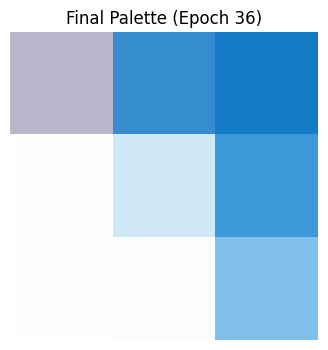

Generated RGB Palette (0-255):
[[185 181 202]
 [ 53 140 206]
 [ 19 123 198]
 [253 254 254]
 [206 232 246]
 [ 59 153 218]
 [254 254 254]
 [251 252 252]
 [129 192 235]]


In [36]:
# Use the correct selected image for palette generation
palette = generate_palette_with_minisom('Screenshot 2026-06-24 203356.png')

print("Generated RGB Palette (0-255):")
print(palette)

## Section 4: 3D Color Space Vector Distribution
Scatter plot of sample image pixel vectors in 3D RGB color space ($R \times G \times B \in [0, 1]^3$) to inspect input manifold density.

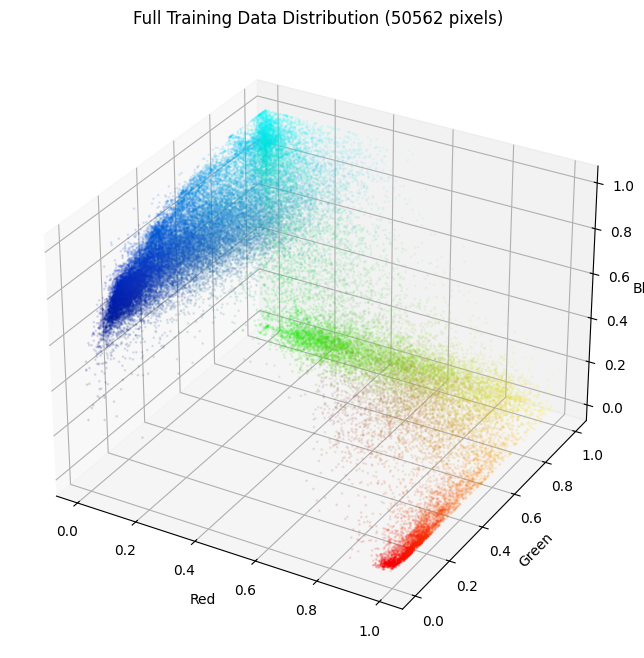

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_all_training_data(image_path):
    img = Image.open(image_path).convert('RGB')
    img_data = np.array(img) / 255.0
    pixels = img_data.reshape(-1, 3)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plotting ALL pixels (note: this may be slow depending on image size)
    ax.scatter(pixels[:, 0], pixels[:, 1], pixels[:, 2],
               c=pixels, s=1, alpha=0.1) # Low alpha to handle density

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(f'Full Training Data Distribution ({len(pixels)} pixels)')
    plt.show()

    return pixels

all_pixels = visualize_all_training_data('images.jpg')